In [1]:
!pip install lxml streamlit pyngrok

  Using cached lxml-6.0.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
  Using cached streamlit-1.47.1-py3-none-any.whl.metadata (9.0 kB)
  Using cached pyngrok-7.2.12-py3-none-any.whl.metadata (9.4 kB)
  Using cached tenacity-9.1.2-py3-none-any.whl.metadata (1.2 kB)
  Using cached toml-0.10.2-py2.py3-none-any.whl.metadata (7.1 kB)
  Using cached watchdog-6.0.0-py3-none-manylinux2014_x86_64.whl.metadata (44 kB)
  Using cached pydeck-0.9.1-py2.py3-none-any.whl.metadata (4.1 kB)
Using cached lxml-6.0.0-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (5.2 MB)
Using cached streamlit-1.47.1-py3-none-any.whl (9.9 MB)
Using cached pyngrok-7.2.12-py3-none-any.whl (26 kB)
Using cached pydeck-0.9.1-py2.py3-none-any.whl (6.9 MB)
Using cached tenacity-9.1.2-py3-none-any.whl (28 kB)
Using cached toml-0.10.2-py2.py3-none-any.whl (16 kB)
Using cached watchdog-6.0.0-py3-none-manylinux2014_x86_64.whl (79 kB)


In [1]:
!pip install pandas

In [2]:
import pandas as pd #Question 5
df_country = pd.read_csv("country_wise_latest.csv")
df_clean = pd.read_csv("covid_19_clean_complete.csv")
df_day = pd.read_csv("day_wise.csv")
df_grouped = pd.read_csv("full_grouped.csv")
df_usa = pd.read_csv("usa_county_wise.csv")
df_worldometer = pd.read_csv("worldometer_data.csv")


In [3]:
def clean_df(df, name=""):
    print(f"Nettoyage du fichier : {name}")
    
    # Noms de colonnes propres
    df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

    # Suppression des doublons
    df.drop_duplicates(inplace=True)

    # Vérifier valeurs manquantes
    print("Valeurs manquantes :")
    print(df.isnull().sum())

    return df

df_country = clean_df(df_country, "country_wise_latest")
df_clean = clean_df(df_clean, "covid_19_clean_complete")
df_day = clean_df(df_day, "day_wise")
df_grouped = clean_df(df_grouped, "full_grouped")
df_usa = clean_df(df_usa, "usa_county_wise")
df_worldometer = clean_df(df_worldometer, "worldometer_data")

Nettoyage du fichier : country_wise_latest
Valeurs manquantes :
country/region            0
confirmed                 0
deaths                    0
recovered                 0
active                    0
new_cases                 0
new_deaths                0
new_recovered             0
deaths_/_100_cases        0
recovered_/_100_cases     0
deaths_/_100_recovered    0
confirmed_last_week       0
1_week_change             0
1_week_%_increase         0
who_region                0
dtype: int64
Nettoyage du fichier : covid_19_clean_complete
Valeurs manquantes :
province/state    34404
country/region        0
lat                   0
long                  0
date                  0
confirmed             0
deaths                0
recovered             0
active                0
who_region            0
dtype: int64
Nettoyage du fichier : day_wise
Valeurs manquantes :
date                      0
confirmed                 0
deaths                    0
recovered                 0
active           

/tmp/ipykernel_2135/3104710735.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_grouped, x='who_region', y='confirmed', palette='OrRd')


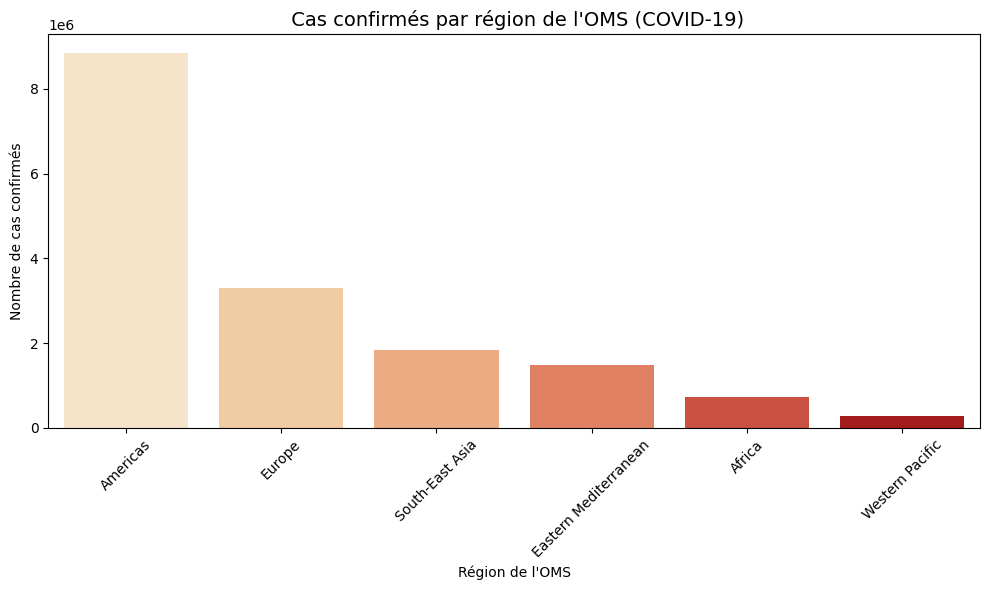

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Charger le fichier CSV
df = pd.read_csv("country_wise_latest.csv")

# Nettoyage des colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Regrouper les cas confirmés par région de l'OMS
region_grouped = df.groupby('who_region')['confirmed'].sum().sort_values(ascending=False).reset_index()

# Tracer l'histogramme (barres verticales)
plt.figure(figsize=(10, 6))
sns.barplot(data=region_grouped, x='who_region', y='confirmed', palette='OrRd')

plt.title(" Cas confirmés par région de l'OMS (COVID-19)", fontsize=14)
plt.xlabel("Région de l'OMS")
plt.ylabel("Nombre de cas confirmés")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

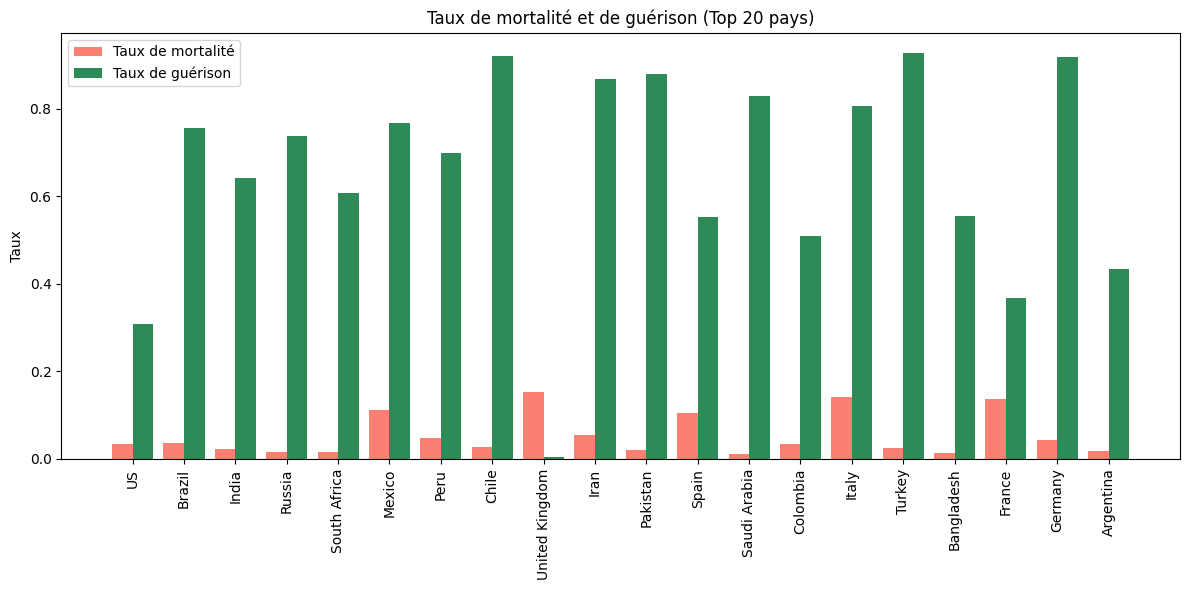

In [6]:
# Calcul des taux
df_country['death_rate'] = df_country['deaths'] / df_country['confirmed']
df_country['recovery_rate'] = df_country['recovered'] / df_country['confirmed']

# Garder les 20 pays avec le plus de cas
top20 = df_country.sort_values(by='confirmed', ascending=False).head(20)

plt.figure(figsize=(12, 6))
bar_width = 0.4
x = range(len(top20))

plt.bar(x, top20['death_rate'], width=bar_width, label="Taux de mortalité", color="salmon")
plt.bar([p + bar_width for p in x], top20['recovery_rate'], width=bar_width, label="Taux de guérison", color="seagreen")

plt.xticks([p + bar_width/2 for p in x], top20['country/region'], rotation=90)
plt.ylabel("Taux")
plt.title("Taux de mortalité et de guérison (Top 20 pays)")
plt.legend()
plt.tight_layout()
plt.show()

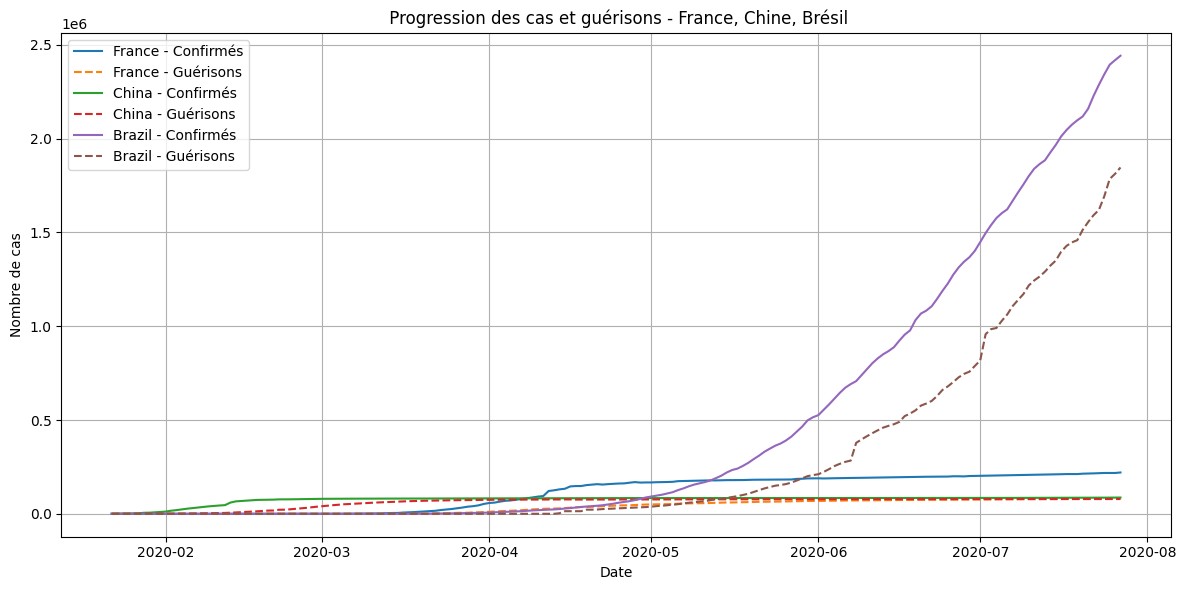

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv("covid_19_clean_complete.csv")
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['date'] = pd.to_datetime(df['date'])

# Pays sélectionnés
countries = ['France', 'China', 'Brazil']

# Filtrer et agréger les données par pays et date
df_filtered = df[df['country/region'].isin(countries)]
df_grouped = df_filtered.groupby(['date', 'country/region'])[['confirmed', 'recovered']].sum().reset_index()

# Tracer les courbes
plt.figure(figsize=(12, 6))

for country in countries:
    country_data = df_grouped[df_grouped['country/region'] == country]
    plt.plot(country_data['date'], country_data['confirmed'], label=f"{country} - Confirmés")
    plt.plot(country_data['date'], country_data['recovered'], linestyle='--', label=f"{country} - Guérisons")

plt.title(" Progression des cas et guérisons - France, Chine, Brésil")
plt.xlabel("Date")
plt.ylabel("Nombre de cas")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [8]:
!pip install plotly


In [9]:
import plotly.io as pio
pio.renderers.default = "notebook"  # ou "iframe_connected" ou "colab" selon ta plateforme
pio.renderers.default = "iframe_connected"  # si ça ne marche toujours pas

In [10]:
import pandas as pd
import plotly.express as px

# Charger le CSV
df = pd.read_csv("covid_19_clean_complete.csv")

# Nettoyer les noms de colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['date'] = pd.to_datetime(df['date'])

# Agréger les cas par pays + coordonnée par date
df_grouped = df.groupby(['date', 'country/region', 'lat', 'long'])[['confirmed', 'deaths']].sum().reset_index()

# Créer une carte animée (scatter geo)
fig = px.scatter_geo(
    df_grouped,
    lat='lat',
    lon='long',
    color='confirmed',
    size='confirmed',
    hover_name='country/region',
    animation_frame=df_grouped['date'].dt.strftime('%Y-%m-%d'),
    projection='natural earth',
    title='Évolution des cas confirmés de COVID-19 dans le monde',
    color_continuous_scale='Reds',
    size_max=50
)

fig.update_layout(geo=dict(showland=True, landcolor="lightgray"))
fig.show()

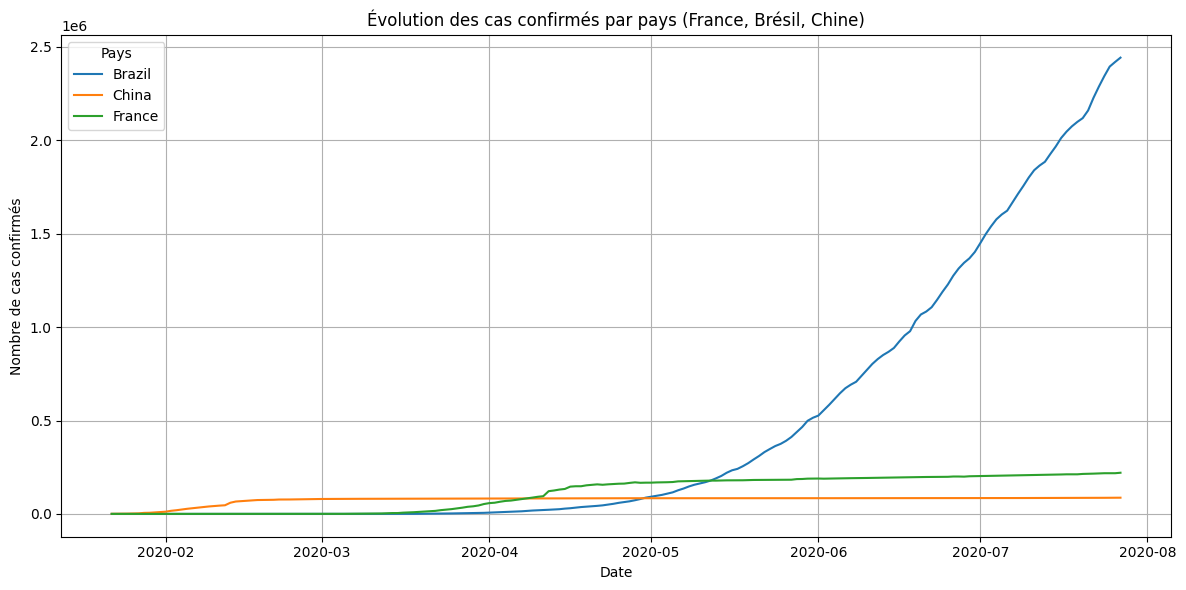

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 🔹 Chargement du fichier CSV
df_covid = pd.read_csv("covid_19_clean_complete.csv")

# 🔹 Nettoyage des noms de colonnes (optionnel mais conseillé)
df_covid.columns = df_covid.columns.str.strip().str.lower().str.replace(' ', '_')

# 🔹 Conversion de la colonne 'date'
df_covid['date'] = pd.to_datetime(df_covid['date'])

# 🔹 Filtrage des pays cibles
pays_selection = ['France', 'Brazil', 'China']
df_pays = df_covid[df_covid['country/region'].isin(pays_selection)]

# 🔹 Agrégation par date et pays
df_pays_agg = df_pays.groupby(['date', 'country/region'])['confirmed'].sum().reset_index()

# 🔹 Visualisation
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_pays_agg, x='date', y='confirmed', hue='country/region')

plt.title("Évolution des cas confirmés par pays (France, Brésil, Chine)")
plt.xlabel("Date")
plt.ylabel("Nombre de cas confirmés")
plt.legend(title="Pays")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
%matplotlib inline
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

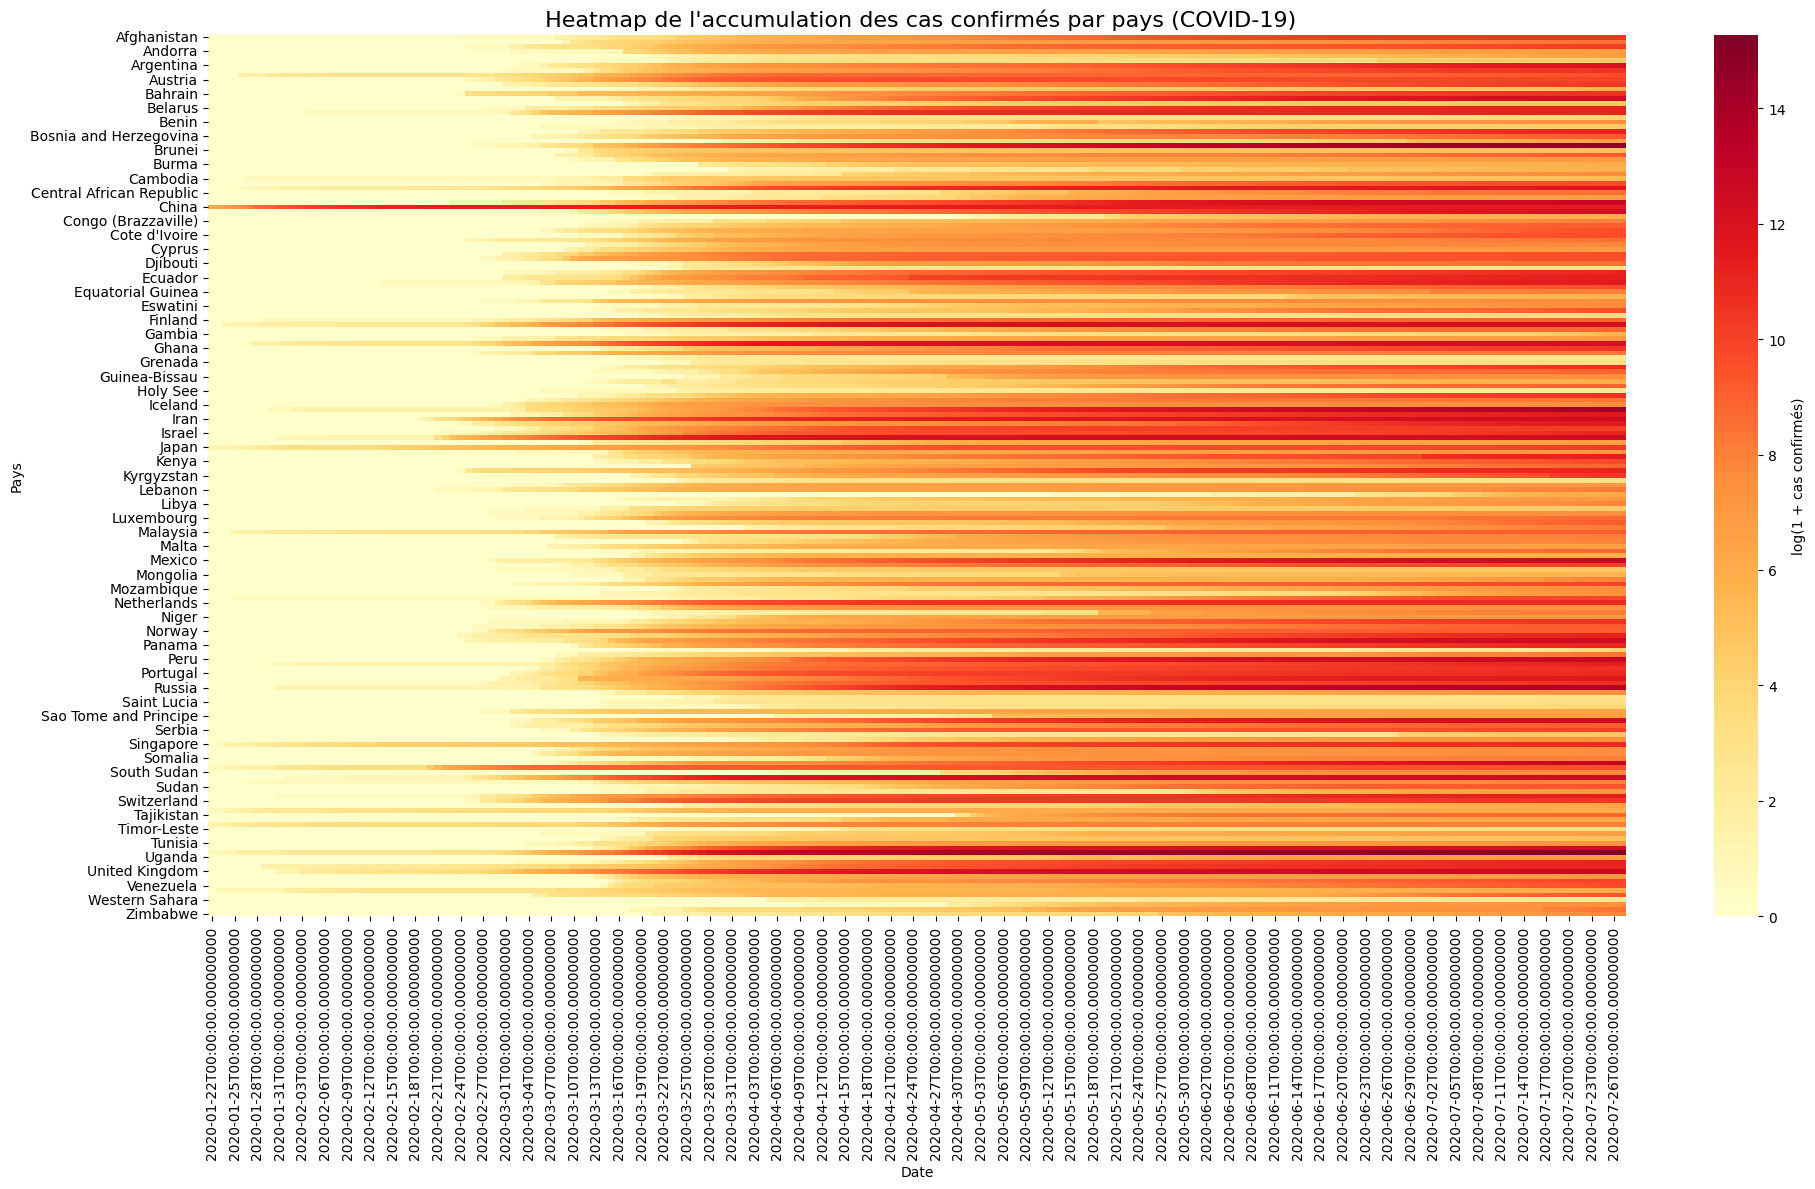

In [13]:
df = pd.read_csv("covid_19_clean_complete.csv")

# Étape 2 : Nettoyer les colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')
df['date'] = pd.to_datetime(df['date'])

# Étape 3 : Regrouper les cas confirmés par date et pays
df_grouped = df.groupby(['date', 'country/region'])['confirmed'].sum().reset_index()

# Étape 4 : Transformer en tableau croisé pour la heatmap
heatmap_data = df_grouped.pivot(index='country/region', columns='date', values='confirmed')
heatmap_data.fillna(0, inplace=True)

# Étape 5 : Logarithme pour lisibilité
heatmap_data_log = np.log1p(heatmap_data)

# Étape 6 : Affichage de la heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(heatmap_data_log, cmap="YlOrRd", cbar_kws={'label': 'log(1 + cas confirmés)'})
plt.title(" Heatmap de l'accumulation des cas confirmés par pays (COVID-19)", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Pays")
plt.tight_layout()
plt.show()

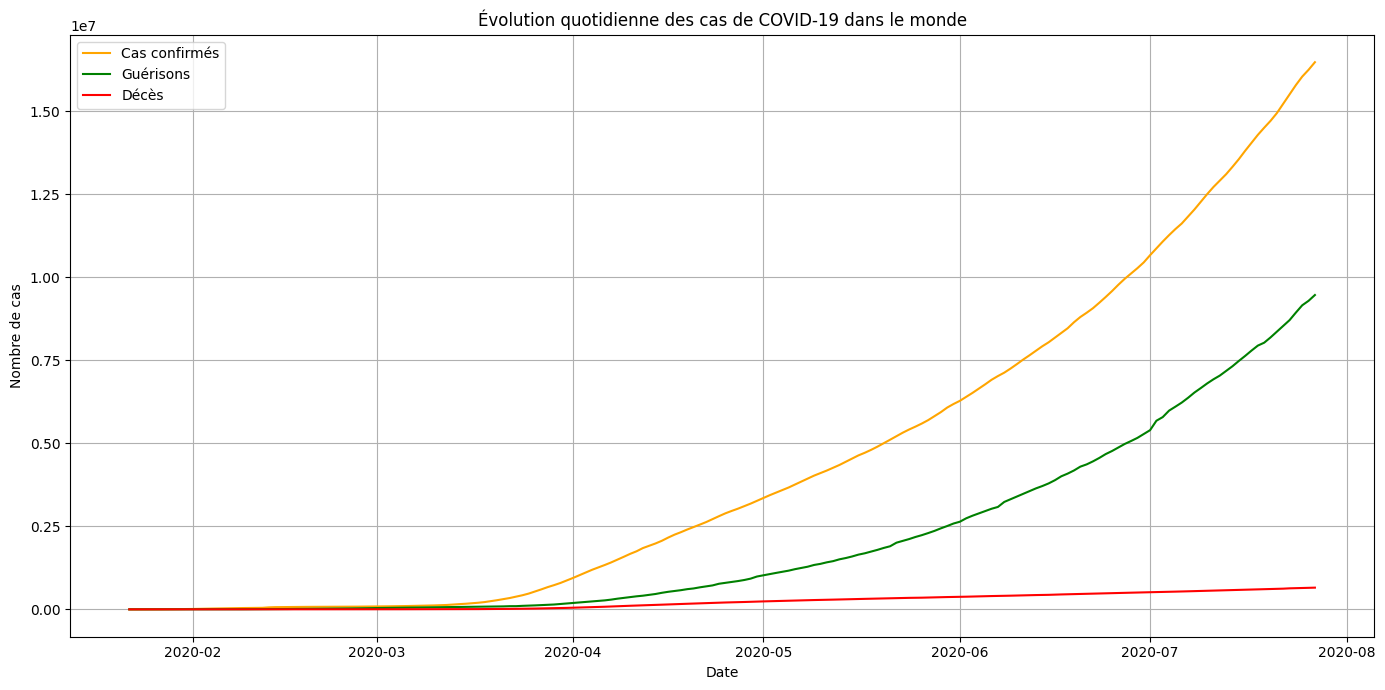

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
df_day = pd.read_csv("day_wise.csv")

# Nettoyer les colonnes (au cas où)
df_day.columns = df_day.columns.str.strip().str.lower().str.replace(' ', '_')

# S'assurer que la colonne 'date' est bien au format datetime
df_day['date'] = pd.to_datetime(df_day['date'])

# Tracer les courbes
plt.figure(figsize=(14, 7))
plt.plot(df_day['date'], df_day['confirmed'], label='Cas confirmés', color='orange')
plt.plot(df_day['date'], df_day['recovered'], label='Guérisons', color='green')
plt.plot(df_day['date'], df_day['deaths'], label='Décès', color='red')

# Ajouter les éléments graphiques
plt.title("Évolution quotidienne des cas de COVID-19 dans le monde")
plt.xlabel("Date")
plt.ylabel("Nombre de cas")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Afficher le graphique
plt.show()

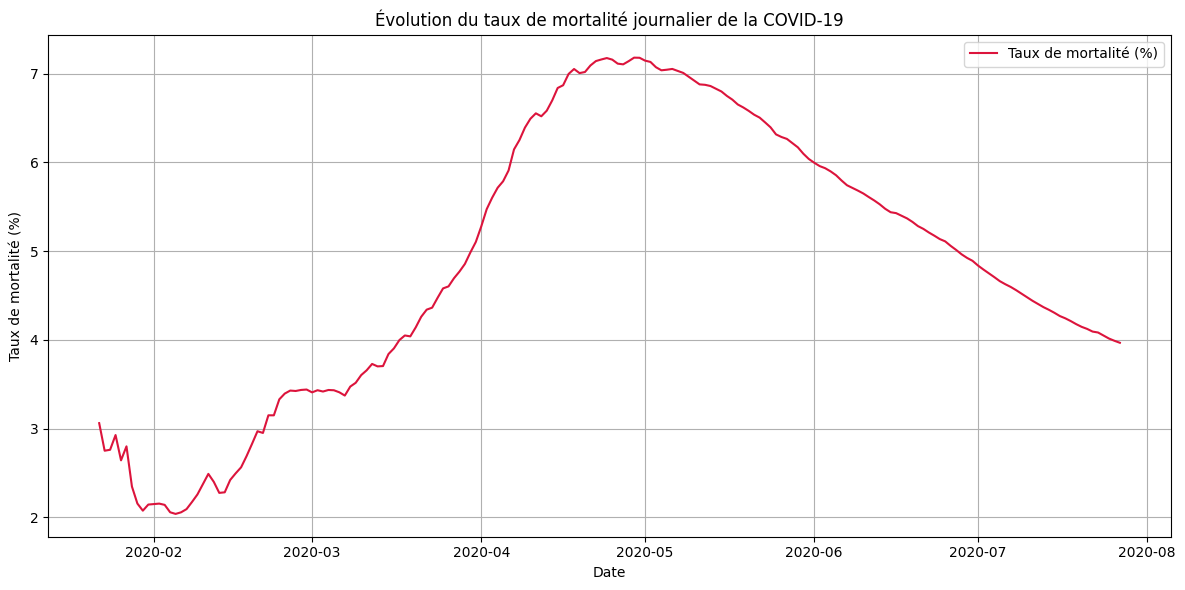

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
df_day = pd.read_csv("day_wise.csv")

# Nettoyer les colonnes
df_day.columns = df_day.columns.str.strip().str.lower().str.replace(' ', '_')

# Conversion de la colonne 'date' en datetime
df_day['date'] = pd.to_datetime(df_day['date'])

# Calcul du taux de mortalité journalier (en pourcentage)
df_day['taux_mortalite'] = (df_day['deaths'] / df_day['confirmed']) * 100
df_day['taux_mortalite'] = df_day['taux_mortalite'].fillna(0)

# Tracer le diagramme
plt.figure(figsize=(12, 6))
plt.plot(df_day['date'], df_day['taux_mortalite'], color='crimson', label='Taux de mortalité (%)')

plt.title("Évolution du taux de mortalité journalier de la COVID-19")
plt.xlabel("Date")
plt.ylabel("Taux de mortalité (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()

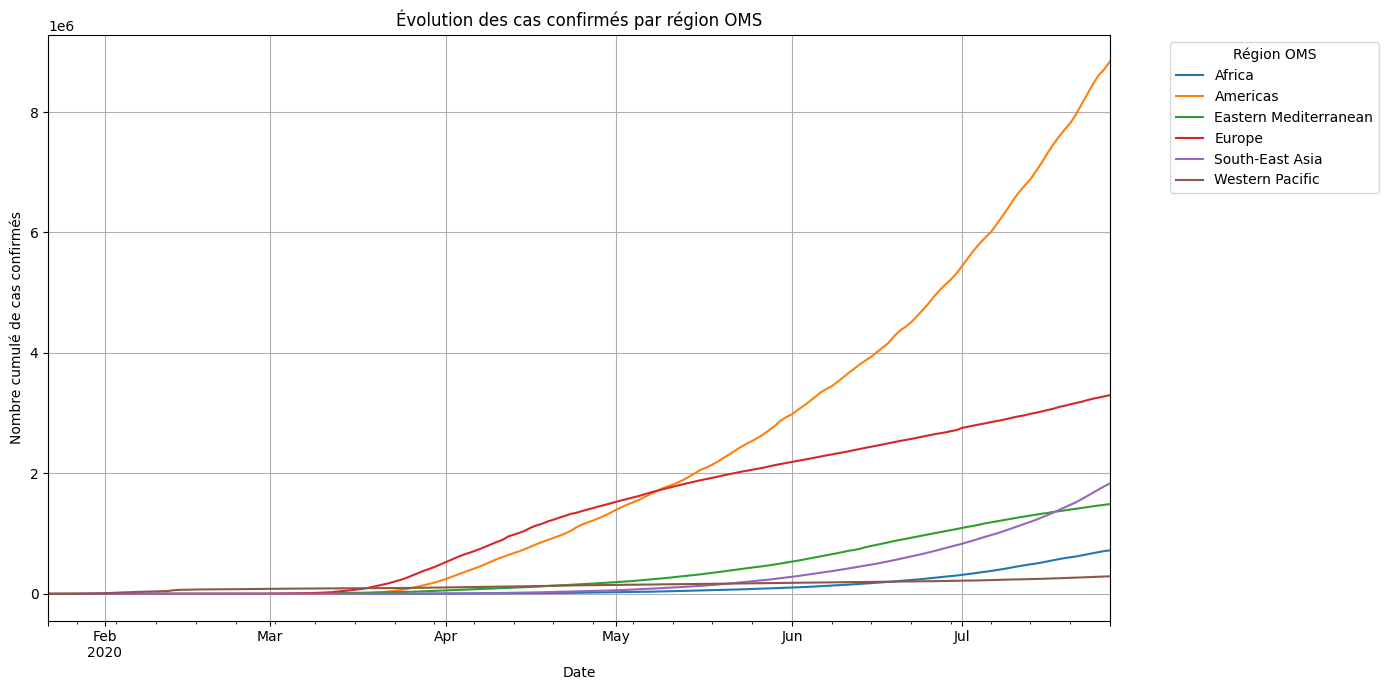

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger les données
df = pd.read_csv("full_grouped.csv")

# Nettoyage des colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Conversion des dates
df['date'] = pd.to_datetime(df['date'])

# On suppose que la colonne 'who_region' existe — à confirmer selon le fichier
# Regrouper par date et région OMS et sommer les cas confirmés
df_region = df.groupby(['date', 'who_region'])['confirmed'].sum().reset_index()

# Pivot table pour visualisation
pivot_df = df_region.pivot(index='date', columns='who_region', values='confirmed')

# Tracé des courbes
plt.figure(figsize=(14, 7))
pivot_df.plot(ax=plt.gca())  # Tracer toutes les régions sur un seul graphique

plt.title("Évolution des cas confirmés par région OMS")
plt.xlabel("Date")
plt.ylabel("Nombre cumulé de cas confirmés")
plt.legend(title="Région OMS", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

plt.show()

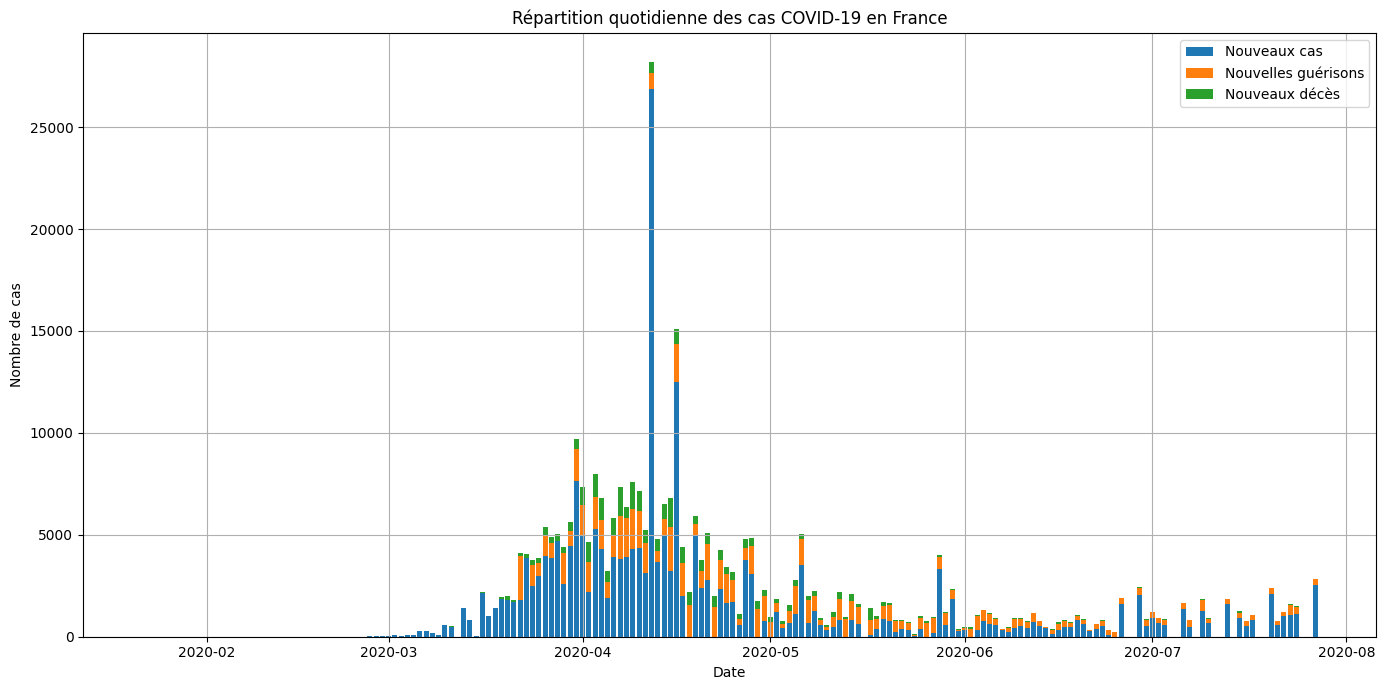

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Charger le fichier CSV
df = pd.read_csv("full_grouped.csv")

# Nettoyage des colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Conversion de la colonne date en datetime
df['date'] = pd.to_datetime(df['date'])

# Choisir un pays (exemple : France)
pays = "France"
df_pays = df[df['country/region'] == pays]

# Sélection des colonnes d'intérêt
df_plot = df_pays[['date', 'new_cases', 'new_deaths', 'new_recovered']]

# Tracé en barres empilées
plt.figure(figsize=(14, 7))
plt.bar(df_plot['date'], df_plot['new_cases'], label='Nouveaux cas')
plt.bar(df_plot['date'], df_plot['new_recovered'], bottom=df_plot['new_cases'], label='Nouvelles guérisons')
plt.bar(df_plot['date'], df_plot['new_deaths'], bottom=df_plot['new_cases'] + df_plot['new_recovered'], label='Nouveaux décès')

plt.title(f"Répartition quotidienne des cas COVID-19 en {pays}")
plt.xlabel("Date")
plt.ylabel("Nombre de cas")
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

In [18]:
import pandas as pd
import plotly.express as px

# Charger le CSV
df = pd.read_csv("usa_county_wise.csv")

# Nettoyage des colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Filtrer les dernières données disponibles pour chaque comté
df_latest = df.sort_values('date').groupby('combined_key').last().reset_index()

# Vérifier qu'on a bien les colonnes nécessaires
# fips : code géographique des comtés (important pour la cartographie)
# confirmed : cas confirmés
# deaths : décès

# CARTOGRAPHIE : Cas confirmés par comté
fig_cases = px.choropleth(
    df_latest,
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    locations='fips',
    color='confirmed',
    color_continuous_scale="Reds",
    scope="usa",
    labels={'confirmed': 'Cas confirmés'},
    title=" Cas confirmés de COVID-19 par comté (USA)"
)
fig_cases.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig_cases.show()

# CARTOGRAPHIE : Décès par comté
fig_deaths = px.choropleth(
    df_latest,
    geojson='https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json',
    locations='fips',
    color='deaths',
    color_continuous_scale="Oranges",
    scope="usa",
    labels={'deaths': 'Décès'},
    title="Décès liés au COVID-19 par comté (USA)"
)
fig_deaths.update_layout(margin={"r":0,"t":30,"l":0,"b":0})
fig_deaths.show()

In [19]:
import pandas as pd

# Charger le fichier
df = pd.read_csv("usa_county_wise.csv")

In [20]:
print(df.columns.tolist())

['UID', 'iso2', 'iso3', 'code3', 'FIPS', 'Admin2', 'Province_State', 'Country_Region', 'Lat', 'Long_', 'Combined_Key', 'Date', 'Confirmed', 'Deaths']


In [21]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [22]:
df['combined_key'].dropna().unique()[:20]

array(['American Samoa, US', 'Guam, US', 'Northern Mariana Islands, US',
       'Adjuntas, Puerto Rico, US', 'Aguada, Puerto Rico, US',
       'Aguadilla, Puerto Rico, US', 'Aguas Buenas, Puerto Rico, US',
       'Aibonito, Puerto Rico, US', 'Anasco, Puerto Rico, US',
       'Arecibo, Puerto Rico, US', 'Arroyo, Puerto Rico, US',
       'Barceloneta, Puerto Rico, US', 'Barranquitas, Puerto Rico, US',
       'Bayamon, Puerto Rico, US', 'Cabo Rojo, Puerto Rico, US',
       'Caguas, Puerto Rico, US', 'Camuy, Puerto Rico, US',
       'Canovanas, Puerto Rico, US', 'Carolina, Puerto Rico, US',
       'Catano, Puerto Rico, US'], dtype=object)

In [23]:
import pandas as pd

# Chargement du fichier
df = pd.read_csv("usa_county_wise.csv")

# Normalisation des colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Conversion correcte de la date
df['date'] = pd.to_datetime(df['date'], format="%m/%d/%y")

# Sélection du dernier jour (les données les plus récentes)
dernier_jour = df['date'].max()
df_last = df[df['date'] == dernier_jour]

# Regrouper par état et calculer les cas confirmés
top_etats = df_last.groupby('province_state')['confirmed'].sum().sort_values(ascending=False).head(10)

# Affichage sous forme de tableau
top_etats_df = top_etats.reset_index()
top_etats_df.columns = ['État', 'Cas Confirmés']

print(top_etats_df)

             État  Cas Confirmés
0      California         458121
1         Florida         432747
2        New York         412344
3           Texas         400336
4      New Jersey         179812
5        Illinois         173894
6         Georgia         170843
7         Arizona         163827
8   Massachusetts         115926
9  North Carolina         114916


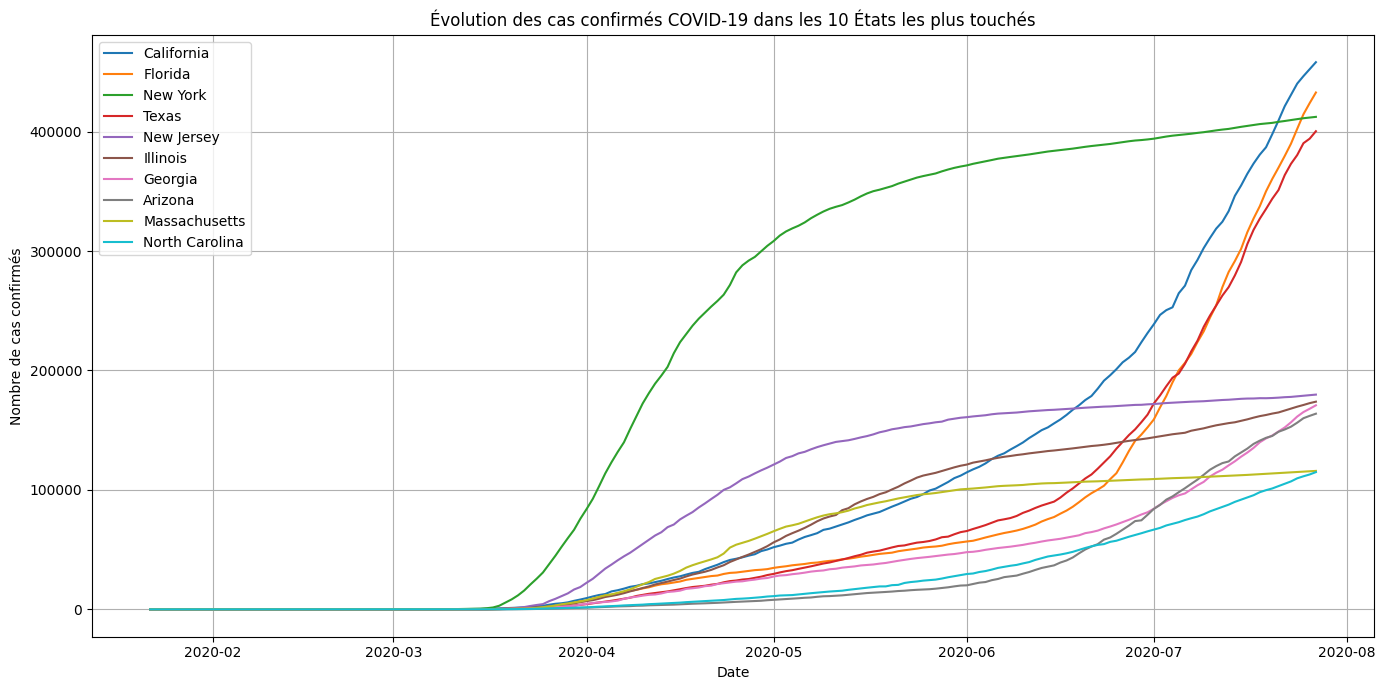

In [24]:
import matplotlib.pyplot as plt

# Choisir les États les plus touchés
etats_cibles = top_etats.index.tolist()

# Filtrer les données pour ces États
df_filtre = df[df['province_state'].isin(etats_cibles)]

# Regrouper par date et État
df_grouped = df_filtre.groupby(['date', 'province_state'])['confirmed'].sum().reset_index()

# Visualisation
plt.figure(figsize=(14, 7))
for etat in etats_cibles:
    data_etat = df_grouped[df_grouped['province_state'] == etat]
    plt.plot(data_etat['date'], data_etat['confirmed'], label=etat)

plt.title("Évolution des cas confirmés COVID-19 dans les 10 États les plus touchés")
plt.xlabel("Date")
plt.ylabel("Nombre de cas confirmés")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

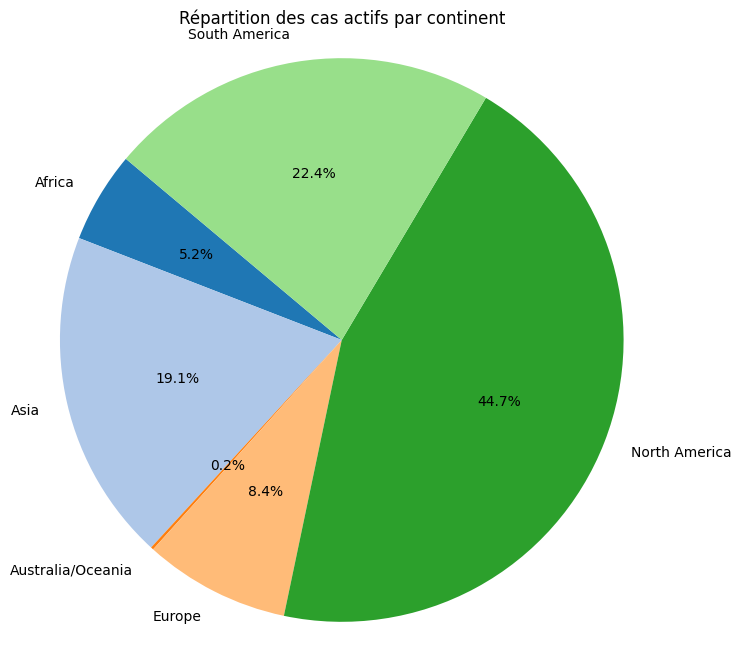

In [25]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement du fichier
df = pd.read_csv("worldometer_data.csv")

# Nettoyage des noms de colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Suppression des lignes avec continent manquant
df = df.dropna(subset=['continent'])

# Regrouper les cas actifs par continent
df_grouped = df.groupby('continent')['activecases'].sum()

# Affichage du diagramme circulaire
plt.figure(figsize=(8, 8))
colors = plt.cm.tab20.colors  # Palette de couleurs

plt.pie(df_grouped, labels=df_grouped.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title("Répartition des cas actifs par continent")
plt.axis('equal')  # cercle parfait
plt.show()

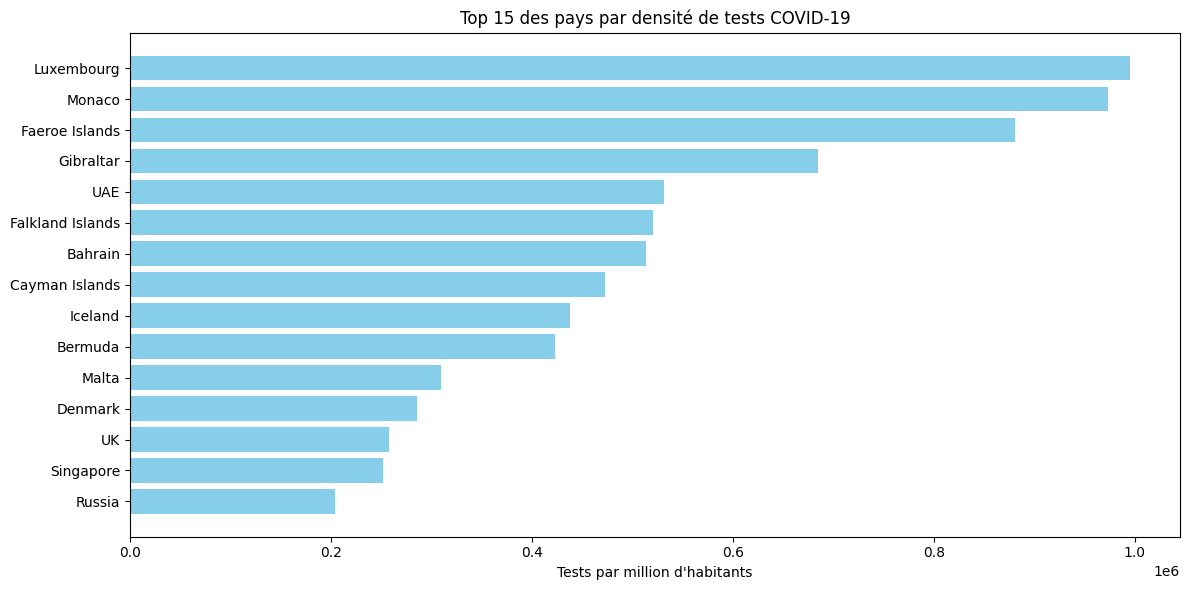

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# Chargement du fichier
df = pd.read_csv("worldometer_data.csv")

# Nettoyage des colonnes
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Suppression des lignes avec données manquantes
df = df.dropna(subset=['tests/1m_pop', 'country/region'])

# Conversion en float si nécessaire (certaines colonnes sont parfois en string)
df['tests/1m_pop'] = df['tests/1m_pop'].astype(float)

# Tri par densité de tests (top 15 pays)
df_top = df.sort_values(by='tests/1m_pop', ascending=False).head(15)

# Graphique
plt.figure(figsize=(12, 6))
plt.barh(df_top['country/region'], df_top['tests/1m_pop'], color='skyblue')
plt.xlabel("Tests par million d'habitants")
plt.title("Top 15 des pays par densité de tests COVID-19")
plt.gca().invert_yaxis()  # Le pays avec le plus grand nombre en haut
plt.tight_layout()
plt.show()

In [ ]:
#Streamlit et app

In [27]:
!pip install lxml streamlit

In [34]:
streamlit hello

SyntaxError: invalid syntax (2773187961.py, line 1)